## Lab 2
### Part 2: Dealing with overfitting

Today we work with [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) (*hint: it is available in `torchvision`*).

Your goal for today:
1. Train a FC (fully-connected) network that achieves >= 0.885 test accuracy.
2. Cause considerable overfitting by modifying the network (e.g. increasing the number of network parameters and/or layers) and demonstrate in in the appropriate way (e.g. plot loss and accurasy on train and validation set w.r.t. network complexity).
3. Try to deal with overfitting (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results.

__Please, write a small report describing your ideas, tries and achieved results in the end of this file.__

*Note*: Tasks 2 and 3 are interrelated, in task 3 your goal is to make the network from task 2 less prone to overfitting. Task 1 is independent from 2 and 3.

*Note 2*: We recomment to use Google Colab or other machine with GPU acceleration.

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchsummary
from IPython.display import clear_output
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import os


device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [ ]:
import random
# import numpy as np
# import torch

# Фиксируем seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Устанавливаем seed
set_seed(42)


In [ ]:
# Technical function
def mkdir(path):
    if not os.path.exists(root_path):
        os.mkdir(root_path)
        print('Directory', path, 'is created!')
    else:
        print('Directory', path, 'already exists!')

root_path = 'fmnist'
mkdir(root_path)

Directory fmnist is created!


In [ ]:
download = True
train_transform = transforms.ToTensor()
test_transform = transforms.ToTensor()
transforms.Compose((transforms.ToTensor()))


fmnist_dataset_train = torchvision.datasets.FashionMNIST(root_path,
                                                        train=True,
                                                        transform=train_transform,
                                                        target_transform=None,
                                                        download=download)
fmnist_dataset_test = torchvision.datasets.FashionMNIST(root_path,
                                                       train=False,
                                                       transform=test_transform,
                                                       target_transform=None,
                                                       download=download)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.80MB/s]


Extracting fmnist/FashionMNIST/raw/train-images-idx3-ubyte.gz to fmnist/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]


Extracting fmnist/FashionMNIST/raw/train-labels-idx1-ubyte.gz to fmnist/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]


Extracting fmnist/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to fmnist/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 7.45MB/s]

Extracting fmnist/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to fmnist/FashionMNIST/raw



In [ ]:
train_loader = torch.utils.data.DataLoader(fmnist_dataset_train,
                                           batch_size=128,
                                           shuffle=True,
                                           num_workers=2)
test_loader = torch.utils.data.DataLoader(fmnist_dataset_test,
                                          batch_size=256,
                                          shuffle=False,
                                          num_workers=2)

In [ ]:
len(fmnist_dataset_test)

10000

In [ ]:
for img, label in train_loader:
    print(img.shape)
#     print(img)
    print(label.shape)
    print(label.size(0))
    break

torch.Size([128, 1, 28, 28])
torch.Size([128])
128


### Task 1
Train a network that achieves $\geq 0.885$ test accuracy. It's fine to use only Linear (`nn.Linear`) layers and activations/dropout/batchnorm. Convolutional layers might be a great use, but we will meet them a bit later.

In [ ]:
class TinyNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),                            # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here
            nn.Linear(input_shape, 512),             # Первый скрытый слой с 512 нейронами
            nn.BatchNorm1d(512),                     # Batch Normalization
            nn.ReLU(),                               # Активация ReLU
            nn.Dropout(0.3),                         # Dropout для регуляризации
            nn.Linear(512, 256),                     # Второй скрытый слой с 256 нейронами
            nn.BatchNorm1d(256),                     # Batch Normalization
            nn.ReLU(),                               # Активация ReLU
            nn.Dropout(0.3),                         # Dropout
            nn.Linear(256, num_classes)              # Выходной слой с 10 нейронами
        )

    def forward(self, inp):
        out = self.model(inp)
        return out


In [ ]:
torchsummary.summary(TinyNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
       BatchNorm1d-3                  [-1, 512]           1,024
              ReLU-4                  [-1, 512]               0
           Dropout-5                  [-1, 512]               0
            Linear-6                  [-1, 256]         131,328
       BatchNorm1d-7                  [-1, 256]             512
              ReLU-8                  [-1, 256]               0
           Dropout-9                  [-1, 256]               0
           Linear-10                   [-1, 10]           2,570
Total params: 537,354
Trainable params: 537,354
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 2.05
Estimated T

Your experiments come here:

In [ ]:
import torch.optim as optim

# Инициализация модели, функции потерь и оптимизатора
model = TinyNeuralNetwork().to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Цикл обучения
num_epochs = 30
train_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    # Обучение на тренировочном наборе
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        predictions = model(x)
        loss = loss_func(predictions, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(predictions.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    train_losses.append(train_loss / len(train_loader))

    # Оценка на тестовом наборе
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x_test, y_test in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            predictions = model(x_test)
            _, predicted_test = torch.max(predictions.data, 1)
            total_test += y_test.size(0)
            correct_test += (predicted_test == y_test).sum().item()

    test_accuracy = correct_test / total_test
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss / len(train_loader):.4f}, Test Accuracy: {test_accuracy:.4f}")

# Финальная оценка точности
print(f"Финальная точность теста: {test_accuracies[-1]:.4f}")


Epoch 1/30, Loss: 0.4821, Test Accuracy: 0.8487
Epoch 2/30, Loss: 0.3719, Test Accuracy: 0.8658
Epoch 3/30, Loss: 0.3384, Test Accuracy: 0.8697
Epoch 4/30, Loss: 0.3170, Test Accuracy: 0.8765
Epoch 5/30, Loss: 0.2992, Test Accuracy: 0.8802
Epoch 6/30, Loss: 0.2865, Test Accuracy: 0.8751
Epoch 7/30, Loss: 0.2688, Test Accuracy: 0.8821
Epoch 8/30, Loss: 0.2629, Test Accuracy: 0.8866
Epoch 9/30, Loss: 0.2512, Test Accuracy: 0.8852
Epoch 10/30, Loss: 0.2463, Test Accuracy: 0.8907
Epoch 11/30, Loss: 0.2356, Test Accuracy: 0.8897
Epoch 12/30, Loss: 0.2286, Test Accuracy: 0.8897
Epoch 13/30, Loss: 0.2220, Test Accuracy: 0.8979
Epoch 14/30, Loss: 0.2139, Test Accuracy: 0.8948
Epoch 15/30, Loss: 0.2079, Test Accuracy: 0.8970
Epoch 16/30, Loss: 0.2001, Test Accuracy: 0.8980
Epoch 17/30, Loss: 0.1930, Test Accuracy: 0.8939
Epoch 18/30, Loss: 0.1922, Test Accuracy: 0.8921
Epoch 19/30, Loss: 0.1856, Test Accuracy: 0.8998
Epoch 20/30, Loss: 0.1792, Test Accuracy: 0.8915
Epoch 21/30, Loss: 0.1747, Te

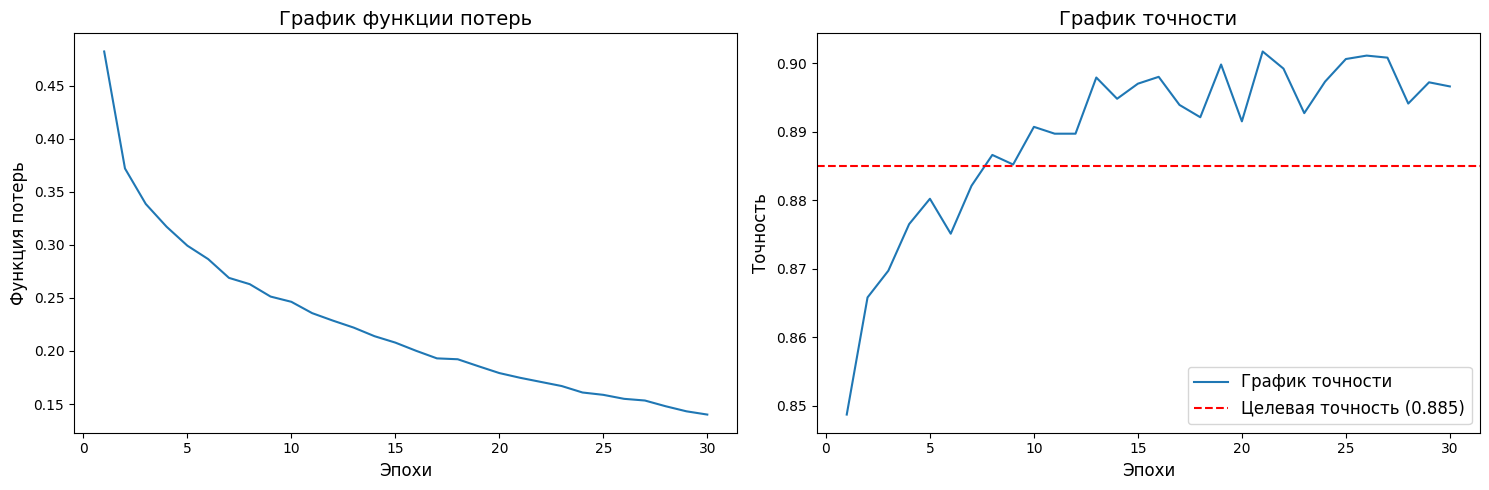

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График функции потерь
ax1.plot(range(1, num_epochs + 1), train_losses)
ax1.set_xlabel("Эпохи", fontsize=12)
ax1.set_ylabel("Функция потерь", fontsize=12)
ax1.set_title("График функции потерь", fontsize=14)

# График точности
ax2.plot(range(1, num_epochs + 1), test_accuracies, label="График точности")
ax2.axhline(0.885, color='r', linestyle='--', label="Целевая точность (0.885)")
ax2.set_xlabel("Эпохи", fontsize=12)
ax2.set_ylabel("Точность", fontsize=12)
ax2.set_title("График точности", fontsize=14)
ax2.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()


### Task 2: Overfit it.
Build a network that will overfit to this dataset. Demonstrate the overfitting in the appropriate way (e.g. plot loss and accurasy on train and test set w.r.t. network complexity).

*Note:* you also might decrease the size of `train` dataset to enforce the overfitting and speed up the computations.

In [ ]:
class OverfittingNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here
            nn.Linear(input_shape, 2048),
            nn.ReLU(),
            nn.Linear(2048, 2048),  # Еще один слой с большим количеством нейронов
            nn.ReLU(),
            nn.Linear(2048, 2048),  # еще слой с большим количеством нейронов
            nn.ReLU(),
            nn.Linear(2048, 2048),  # еще слой с большим количеством нейронов
            nn.ReLU(),
            nn.Linear(2048, 2048),  # и еще слой с большим количеством нейронов
            nn.ReLU(),
            nn.Linear(2048, num_classes)  # Выходной слой
        )

    def forward(self, inp):
        out = self.model(inp)
        return out

In [ ]:
torchsummary.summary(OverfittingNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                 [-1, 2048]       1,607,680
              ReLU-3                 [-1, 2048]               0
            Linear-4                 [-1, 2048]       4,196,352
              ReLU-5                 [-1, 2048]               0
            Linear-6                 [-1, 2048]       4,196,352
              ReLU-7                 [-1, 2048]               0
            Linear-8                 [-1, 2048]       4,196,352
              ReLU-9                 [-1, 2048]               0
           Linear-10                 [-1, 2048]       4,196,352
             ReLU-11                 [-1, 2048]               0
           Linear-12                   [-1, 10]          20,490
Total params: 18,413,578
Trainable params: 18,413,578
Non-trainable params: 0
-------------------------

In [ ]:
model = OverfittingNeuralNetwork().to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001) # YOUR CODE HERE
loss_func = nn.CrossEntropyLoss() # YOUR CODE HERE

# Your experiments, come here

In [ ]:
# Уменьшаем размер обучающего набора данных
small_train_set = torch.utils.data.Subset(fmnist_dataset_train, range(1000))
small_train_loader = torch.utils.data.DataLoader(small_train_set, batch_size=128, shuffle=True, num_workers=2)


In [ ]:
# Функция для обучения модели
def train_model(model, train_loader, test_loader, loss_func, opt, num_epochs):
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(num_epochs):
        # Обучение
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            predictions = model(x)
            loss = loss_func(predictions, y)
            loss.backward()
            opt.step()
            running_loss += loss.item()
            _, predicted = torch.max(predictions, 1)
            total_train += y.size(0)
            correct_train += (predicted == y).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(correct_train / total_train)

        # Тестирование
        model.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                predictions = model(x)
                loss = loss_func(predictions, y)
                test_loss += loss.item()
                _, predicted = torch.max(predictions, 1)
                total_test += y.size(0)
                correct_test += (predicted == y).sum().item()

        test_losses.append(test_loss / len(test_loader))
        test_accuracies.append(correct_test / total_test)

        # Красивый вывод результатов
        print(f"Epoch {epoch + 1}/{num_epochs} - "
              f"Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}, "
              f"Train Accuracy: {train_accuracies[-1]:.4f}, Test Accuracy: {test_accuracies[-1]:.4f}")

    return train_losses, test_losses, train_accuracies, test_accuracies

In [ ]:
def plot_metrics(num_epochs, train_losses, test_losses, train_accuracies, test_accuracies):
    # График потерь и точности
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))  # 1 строка, 2 столбца

    # График функции потерь
    ax1.plot(range(1, num_epochs + 1), train_losses, label="на обучающих данных")
    ax1.plot(range(1, num_epochs + 1), test_losses, label="на тестирующих данных")
    ax1.set_xlabel("Эпохи", fontsize=12)
    ax1.set_ylabel("Потери", fontsize=12)
    ax1.set_title("Функция потерь при обучении и тестировании", fontsize=14)
    ax1.legend(loc='upper right', fontsize=12)
    ax1.grid(True)
    #ax1.set_ylim(0, 2.5)
    # График точности
    ax2.plot(range(1, num_epochs + 1), train_accuracies, label="на обучающих данных")
    ax2.plot(range(1, num_epochs + 1), test_accuracies, label="на тестирующих данных")
    ax2.set_xlabel("Эпохи", fontsize=12)
    ax2.set_ylabel("Точность", fontsize=12)
    ax2.set_title("Точность при обучении и тестировании", fontsize=14)
    ax2.legend(loc='lower right', fontsize=12)
    ax2.grid(True)
    #ax2.set_ylim(0, 1.0)
    plt.tight_layout()  # Автоматическое распределение элементов
    plt.show()

In [ ]:
# Обучение модели на меньшем наборе данных
train_losses, test_losses, train_accuracies, test_accuracies = train_model(model, small_train_loader, test_loader, loss_func, opt, num_epochs=50)


Epoch 1/50 - Train Loss: 2.0483, Test Loss: 1.7134, Train Accuracy: 0.1860, Test Accuracy: 0.3774
Epoch 2/50 - Train Loss: 1.4246, Test Loss: 1.3432, Train Accuracy: 0.4770, Test Accuracy: 0.4737
Epoch 3/50 - Train Loss: 1.1662, Test Loss: 1.0738, Train Accuracy: 0.5170, Test Accuracy: 0.6014
Epoch 4/50 - Train Loss: 0.9966, Test Loss: 1.1597, Train Accuracy: 0.6130, Test Accuracy: 0.5461
Epoch 5/50 - Train Loss: 0.9541, Test Loss: 0.9322, Train Accuracy: 0.5860, Test Accuracy: 0.5356
Epoch 6/50 - Train Loss: 0.7843, Test Loss: 0.8255, Train Accuracy: 0.6530, Test Accuracy: 0.6792
Epoch 7/50 - Train Loss: 0.6601, Test Loss: 0.8374, Train Accuracy: 0.7250, Test Accuracy: 0.6732
Epoch 8/50 - Train Loss: 0.5966, Test Loss: 0.7701, Train Accuracy: 0.7450, Test Accuracy: 0.7295
Epoch 9/50 - Train Loss: 0.5223, Test Loss: 0.8886, Train Accuracy: 0.7830, Test Accuracy: 0.7272
Epoch 10/50 - Train Loss: 0.5181, Test Loss: 0.8422, Train Accuracy: 0.8020, Test Accuracy: 0.7346
Epoch 11/50 - Train

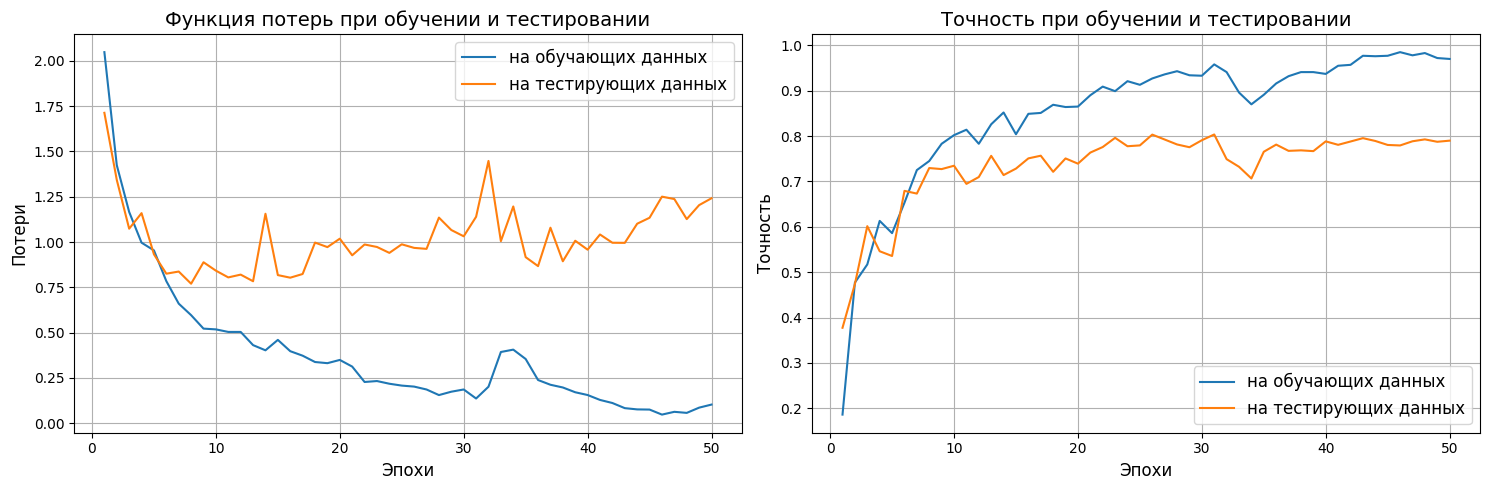

In [ ]:
# Построение графиков
plot_metrics(50, train_losses, test_losses, train_accuracies, test_accuracies)

### Task 3: Fix it.
Fix the overfitted network from the previous step (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results.

In [ ]:
class FixedNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),  # Конвертирует изображение в вектор
            nn.Linear(input_shape, 2048),
            nn.BatchNorm1d(2048),  # BatchNorm для стабилизации обучения
            nn.ReLU(),
            nn.Dropout(0.9),  # Dropout для уменьшения переобучения
            nn.Linear(2048, 2048),
            nn.BatchNorm1d(2048),  # BatchNorm для следующего слоя
            nn.ReLU(),
            nn.Dropout(0.7),  # Dropout
            nn.Linear(2048, 2048),
            nn.BatchNorm1d(2048),  # BatchNorm для следующего слоя
            nn.ReLU(),
            nn.Dropout(0.7),
            nn.Linear(2048, 2048),
            nn.BatchNorm1d(2048),  # BatchNorm для следующего слоя
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout
            nn.Linear(2048, num_classes)  # Выходной слой с количеством классов
        )

    def forward(self, inp):
        return self.model(inp)


In [ ]:
torchsummary.summary(FixedNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                 [-1, 2048]       1,607,680
       BatchNorm1d-3                 [-1, 2048]           4,096
              ReLU-4                 [-1, 2048]               0
           Dropout-5                 [-1, 2048]               0
            Linear-6                 [-1, 2048]       4,196,352
       BatchNorm1d-7                 [-1, 2048]           4,096
              ReLU-8                 [-1, 2048]               0
           Dropout-9                 [-1, 2048]               0
           Linear-10                 [-1, 2048]       4,196,352
      BatchNorm1d-11                 [-1, 2048]           4,096
             ReLU-12                 [-1, 2048]               0
          Dropout-13                 [-1, 2048]               0
           Linear-14                 [-

In [ ]:
model = FixedNeuralNetwork().to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001) # YOUR CODE HERE
loss_func = nn.CrossEntropyLoss()# YOUR CODE HERE

# Your experiments, come here

In [ ]:
train_losses, test_losses, train_accuracies, test_accuracies = train_model(model, small_train_loader, test_loader, loss_func, opt, num_epochs=50)


Epoch 1/50 - Train Loss: 2.2750, Test Loss: 2.0798, Train Accuracy: 0.1710, Test Accuracy: 0.3750
Epoch 2/50 - Train Loss: 1.6086, Test Loss: 1.2246, Train Accuracy: 0.4200, Test Accuracy: 0.5434
Epoch 3/50 - Train Loss: 1.2480, Test Loss: 0.9309, Train Accuracy: 0.5420, Test Accuracy: 0.6251
Epoch 4/50 - Train Loss: 1.0787, Test Loss: 0.9478, Train Accuracy: 0.6220, Test Accuracy: 0.6736
Epoch 5/50 - Train Loss: 0.9078, Test Loss: 0.8097, Train Accuracy: 0.6570, Test Accuracy: 0.7134
Epoch 6/50 - Train Loss: 0.9151, Test Loss: 0.7633, Train Accuracy: 0.6670, Test Accuracy: 0.7247
Epoch 7/50 - Train Loss: 0.9085, Test Loss: 0.7166, Train Accuracy: 0.6570, Test Accuracy: 0.7243
Epoch 8/50 - Train Loss: 0.8429, Test Loss: 0.7218, Train Accuracy: 0.6950, Test Accuracy: 0.7274
Epoch 9/50 - Train Loss: 0.8184, Test Loss: 0.6802, Train Accuracy: 0.6890, Test Accuracy: 0.7446
Epoch 10/50 - Train Loss: 0.7437, Test Loss: 0.6587, Train Accuracy: 0.7290, Test Accuracy: 0.7405
Epoch 11/50 - Train

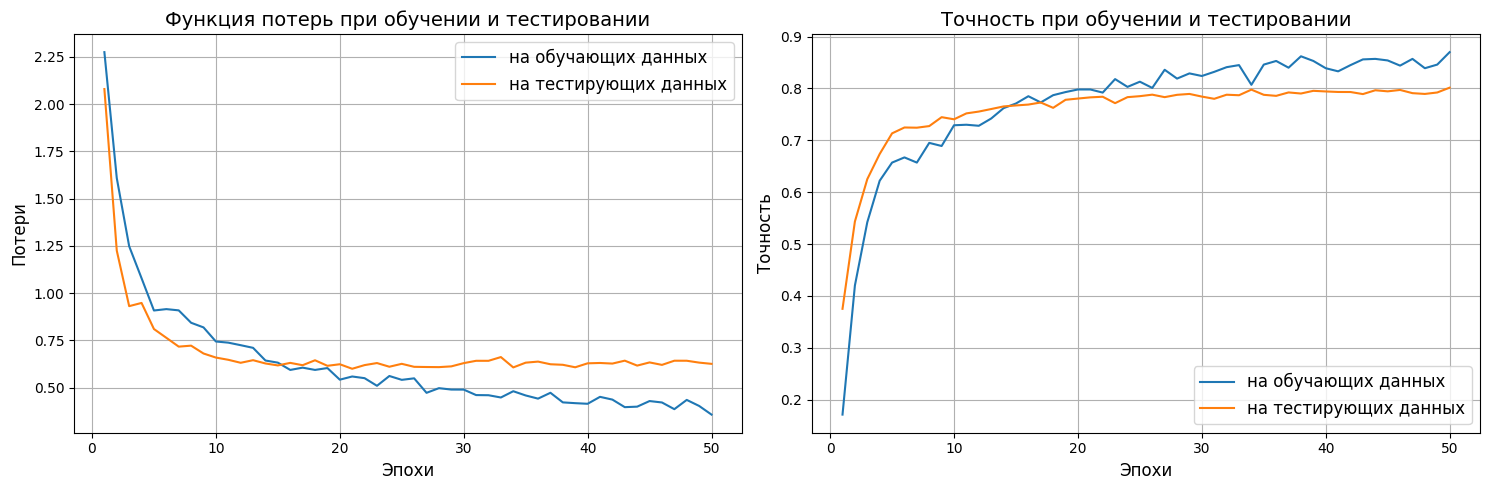

In [ ]:
plot_metrics(50, train_losses, test_losses, train_accuracies, test_accuracies)

In [ ]:
class FixedNeuralNetwork_moreData(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),  # Конвертирует изображение в вектор
            nn.Linear(input_shape, 2048),
            nn.BatchNorm1d(2048),  # BatchNorm для стабилизации обучения
            nn.ReLU(),
            nn.Dropout(0.9),  # Dropout для уменьшения переобучения
            nn.Linear(2048, 2048),
            nn.BatchNorm1d(2048),  # BatchNorm для следующего слоя
            nn.ReLU(),
            nn.Dropout(0.7),  # Dropout
            nn.Linear(2048, 2048),
            nn.BatchNorm1d(2048),  # BatchNorm для следующего слоя
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout
            nn.Linear(2048, num_classes)  # Выходной слой с количеством классов
        )

    def forward(self, inp):
        return self.model(inp)


In [ ]:
torchsummary.summary(FixedNeuralNetwork_moreData().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                 [-1, 2048]       1,607,680
       BatchNorm1d-3                 [-1, 2048]           4,096
              ReLU-4                 [-1, 2048]               0
           Dropout-5                 [-1, 2048]               0
            Linear-6                 [-1, 2048]       4,196,352
       BatchNorm1d-7                 [-1, 2048]           4,096
              ReLU-8                 [-1, 2048]               0
           Dropout-9                 [-1, 2048]               0
           Linear-10                 [-1, 2048]       4,196,352
      BatchNorm1d-11                 [-1, 2048]           4,096
             ReLU-12                 [-1, 2048]               0
          Dropout-13                 [-1, 2048]               0
           Linear-14                   

In [ ]:
model = FixedNeuralNetwork_moreData().to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001) # YOUR CODE HERE
loss_func = nn.CrossEntropyLoss()# YOUR CODE HERE

# Your experiments, come here

In [ ]:
train_losses, test_losses, train_accuracies, test_accuracies = train_model(model, train_loader, test_loader, loss_func, opt, num_epochs=50)

Epoch 1/50 - Train Loss: 0.7199, Test Loss: 0.4847, Train Accuracy: 0.7359, Test Accuracy: 0.8246
Epoch 2/50 - Train Loss: 0.5635, Test Loss: 0.4550, Train Accuracy: 0.7948, Test Accuracy: 0.8325
Epoch 3/50 - Train Loss: 0.5243, Test Loss: 0.4299, Train Accuracy: 0.8102, Test Accuracy: 0.8374
Epoch 4/50 - Train Loss: 0.4935, Test Loss: 0.4146, Train Accuracy: 0.8208, Test Accuracy: 0.8512
Epoch 5/50 - Train Loss: 0.4836, Test Loss: 0.3995, Train Accuracy: 0.8232, Test Accuracy: 0.8510
Epoch 6/50 - Train Loss: 0.4701, Test Loss: 0.3900, Train Accuracy: 0.8292, Test Accuracy: 0.8577
Epoch 7/50 - Train Loss: 0.4579, Test Loss: 0.3836, Train Accuracy: 0.8340, Test Accuracy: 0.8540
Epoch 8/50 - Train Loss: 0.4480, Test Loss: 0.3863, Train Accuracy: 0.8369, Test Accuracy: 0.8574
Epoch 9/50 - Train Loss: 0.4360, Test Loss: 0.3784, Train Accuracy: 0.8411, Test Accuracy: 0.8614
Epoch 10/50 - Train Loss: 0.4292, Test Loss: 0.3756, Train Accuracy: 0.8437, Test Accuracy: 0.8631
Epoch 11/50 - Train

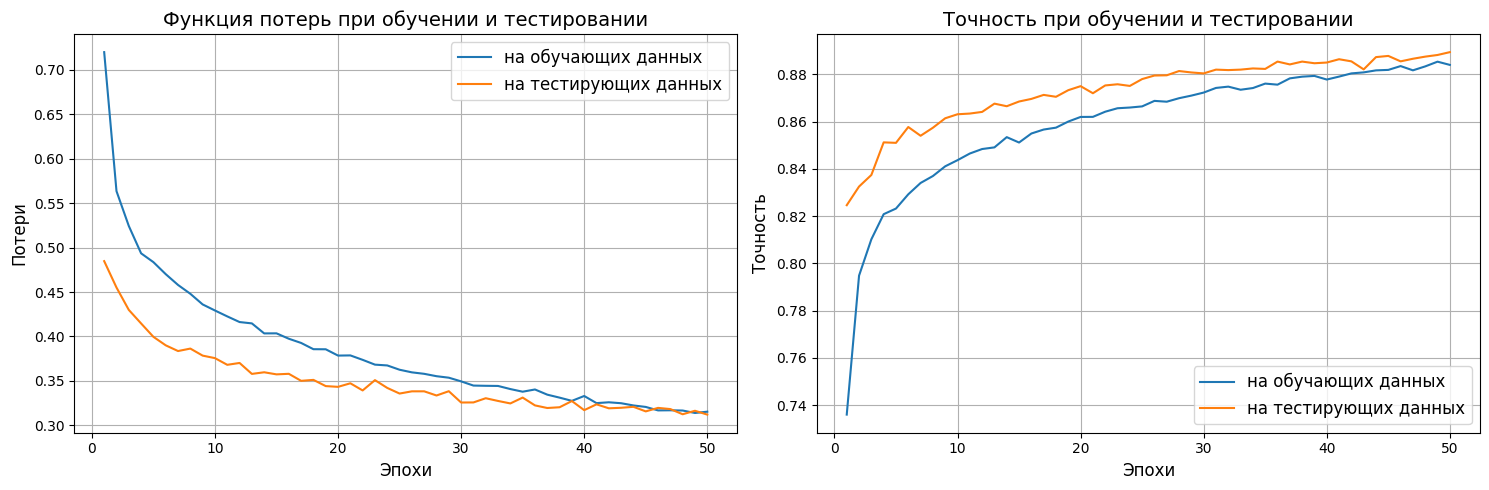

In [ ]:
plot_metrics(50, train_losses, test_losses, train_accuracies, test_accuracies)

### Conclusions:
_Write down small report with your conclusions and your ideas._

Заключение:
В ходе выполнения лабораторной работы, целью которой было преодоление переобучения модели на датасете Fashion-MNIST, было сделано следующее:

Была создана базовая модель с несколькими слоями nn.Linear и функциями активации для достижения целевой точности ≥0.885.

Модель с переобучением (Task 2):

Для того чтобы показать явное переобучение, модель была значительно увеличена путем добавления большего количества слоев и нейронов, а также уменьшения размер обучающего набора данных. Это привело к улучшению метрик качества на обучающем наборе данных, но к ухудшению результатов на тестовом наборе — очевидное проявление переобучения.

Уменьшение переобучения с помощью регуляризации (Task 3):

Для борьбы с переобучением были использовали две основные техники регуляризации:
Dropout - случайное исключение части нейронов на каждой итерации для предотвращения запоминания модели.
BatchNormalization - нормализация активаций на каждом слое, чтобы ускорить обучение и стабилизировать градиенты.
Эти методы позволили значительно улучшить стабильность модели и уменьшить переобучение. Точность на тестовом наборе данных улучшилась, и модель стала менее склонна к запоминанию обучающих данных.

Тем не менее, точность на обучающих данных превышает таковую на тестовых. Увеличение размера обучающего набора данных позволила изменить ситуацию - точность на тестовых данных превысила таковую на обучающих.
